# <h1 style="color: yellow;">Genetic Algorithm Model (second alternative model)</h1>

In [1]:
#Notes:
    #Ga -> Genetic Algorithm.
    #Can we improve the model by automatically finding the best subset of variables?
    #However, it is important to note that to use this model, we need to combine it with a linear regression model, since the Genetic Algorithm (GA) model will return the best combination of variables.
    #This way, we can evaluate whether the GA is truly able to find a configuration that improves upon our baseline.

## Libraries

In [2]:
#Call libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

## Functions

In [3]:
#Function that will select which factors allow the model to generalize better to data not used during training
def fitness_function(solution):
    '''
        The lower the RMSE, the better the solution.
        Using the cross-validation method, we will obtain a mean squared error for 5-fold cross-validation.
    '''

    selected_features = solution == 1

    #Avoid solutions with no selected features
    if selected_features.sum() == 0:
        return float("inf")

    X_selected = X_train_processed[:, selected_features]

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    #Now the GA seeks a solution that performs well outside the training sample, rather than simply a solution that memorizes X_train.
    return -scores.mean()

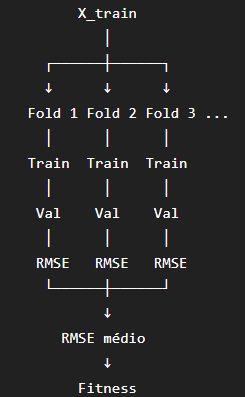

In [4]:
#Selection
#Function to select the best individual that will win the comparison contest
def tournament_selection(population, fitness_scores):

    '''
        We pick two individuals at random and let the best one win.
    '''
    
    idx1, idx2 = np.random.choice(
        len(population),
        size=2,
        replace=False
    )

    if fitness_scores[idx1] < fitness_scores[idx2]:
        return population[idx1]
    else:
        return population[idx2]

In [5]:
#Crossover
#Function to concatenate the algorithms of two individuals at a random crossover point, generating an offspring with the genetic characteristics of both.
def crossover(parent1, parent2):
    '''
        Function to concatenate the algorithms of two individuals at a random crossover point, 
        generating an offspring with the genetic characteristics of both.
    '''

    #The selection will be made by a draw.
    point = np.random.randint(
        1,
        len(parent1)
    )

    child = np.concatenate([
        parent1[:point],
        parent2[point:]
    ])

    return child

In [6]:
#Mutation
#Function that randomly alters a child's genes based on a probability rate.
def mutation(child, mutation_rate):
    '''
        Function that randomly alters a child's genes based on a probability rate.
    '''
    for i in range(len(child)):

        if np.random.rand() < mutation_rate:
            child[i] = 1 - child[i]

    return child

## Training and tests variables import

In [7]:
#Import 80/20 model
import sys
sys.path.append("../")

from src.training_test_variables_80_20 import (
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test
)

## One-Hot encoding

In [8]:
#Columns type identification
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist() #-> 14

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() #-> 6

#Create the categorical columns preprocessing (the combination of values will result in 34 new categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough" #The numeric columns will pass directly
)
#Note:
#The `handle_unknown="ignore"` setting is important. Imagine a category appearing in `X_test` that didn't exist in `X_train`. The encoder won't break.

## Data transformation process (GA - initial step)

In [9]:
#GA selecting the 40 features after preprocessing.

#Data transformation process
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Features definition
feature_names = preprocessor.get_feature_names_out()

#We have 40 features now
print(feature_names)
print(X_train_processed.shape)
print(X_test_processed.shape)

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Internet_Access_yes' 'categorical__Family_Income_high'
 'categorical__Family_Income_low' 'categorical__Family_Income_medium'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__Teacher_Quality_medium' 'categorical__School_Type_private'
 'categorical__School_Type_public' 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_no'
 'categorical__Learning_Disa

## Manual determination of the best solution (GA - addtional step)

In [10]:
#First, we need to create an initial population.
n_features = X_train_processed.shape[1]
population_size = 600 #Just an example based on a fraction of the original quantity (~6,000).
#The population size is directly related to the computational cost.

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)

print(population.shape)

(600, 40)


In [11]:
#Then, we evaluate each individual using our fitness_function.
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)

print(fitness_scores)

[np.float64(2.391636303277207), np.float64(3.6480341245526082), np.float64(2.7235166596580647), np.float64(2.1941036265187743), np.float64(2.0869092201731934), np.float64(2.732232644483763), np.float64(3.269203521396661), np.float64(2.2610287617517666), np.float64(3.2865295599993565), np.float64(3.206035188722111), np.float64(3.2667970220858487), np.float64(2.7718931446231005), np.float64(3.2267403138580577), np.float64(3.7008119141163185), np.float64(2.87032712945749), np.float64(2.245614818049257), np.float64(2.773290860105776), np.float64(3.5717291832525335), np.float64(3.128035832859589), np.float64(3.600520504566913), np.float64(3.222039023386606), np.float64(3.1617048833396875), np.float64(2.8015666690839485), np.float64(3.1627250499126838), np.float64(2.286466291822624), np.float64(3.124710953708152), np.float64(2.863217665706983), np.float64(3.131519518915932), np.float64(2.2230317617244526), np.float64(3.6003976728376728), np.float64(2.347906402546398), np.float64(2.4197061113

In [12]:
#Since a lower RMSE is better, we can find the index of the best one.
best_index = np.argmin(fitness_scores) #returns the index (the position) of the smallest value in a NumPy array
print(best_index)

#Finally the best solution variables combination
best_solution = population[best_index]
print(best_solution)

468
[1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0
 1 1 0]


In [13]:
#Finally the best solution variables combination (names)
selected_features = feature_names[best_solution == 1]
print(selected_features)

#Notes:
   #This is still just the first generation.
   #We identified the best individual from the initial population, but we haven't yet found the truly "genetic" part.

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Family_Income_high' 'categorical__Family_Income_low'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__School_Type_public' 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_yes'
 'categorical__Parental_Education_Level_postgraduate'
 'categorical__Distance_from_Home_near' 'remainder__Hours_Studied'
 'remainder__Attendance' 'remainder__Previous_Scores'
 'remainder__Tutoring_Sessions']


In [14]:
#Model training with the best solution found by the GA
X_train_ga = X_train_processed[:, best_solution == 1]
X_test_ga = X_test_processed[:, best_solution == 1]

model_ga = LinearRegression()

model_ga.fit(X_train_ga, y_train)

#Model predict
y_pred_ga = model_ga.predict(X_test_ga)

## Construction of the complete genetic algorithm model

### Genetic Algorithm Parameters

In [15]:
#Initial parameters
population_size = 600
n_generations = 30
mutation_rate = 0.05

#Notes:
    #population_size: 600 solutions per generation -> x 5 folds in fitness function = 3000 training runs
    #n_generations: the algorithm will evolve for 30 generations
    #mutation_rate: 5% chance of each gene undergoing mutation

### Create the initial population

In [16]:
n_features = X_train_processed.shape[1]

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)
display(population)

array([[0, 1, 0, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 1, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]], shape=(600, 40))

### Assess the population


In [17]:
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)
    
print(fitness_scores)
#Attetion -> The lower the RMSE, the better the individual.

[np.float64(3.204173023626217), np.float64(3.147761686761131), np.float64(3.212580395965927), np.float64(3.6147532975560352), np.float64(3.6819418744439845), np.float64(3.642585688968758), np.float64(2.249224361870944), np.float64(3.6127366827222445), np.float64(3.6068131642758106), np.float64(3.086969334249532), np.float64(2.205984611769124), np.float64(2.754585077844183), np.float64(2.269949051678627), np.float64(2.19336936072699), np.float64(3.2120854147106064), np.float64(3.3335449924216958), np.float64(2.2454700874352316), np.float64(3.245177339688099), np.float64(2.7867482248271136), np.float64(3.7125470425654425), np.float64(3.7145260637042896), np.float64(3.1403717693062374), np.float64(3.2146318906056406), np.float64(2.136252987301226), np.float64(3.2193350956366364), np.float64(2.9168218026134034), np.float64(2.236297445024242), np.float64(3.695682439787145), np.float64(3.637679813416743), np.float64(2.23164747128694), np.float64(3.10383785691069), np.float64(3.18087102224883

### Finding the best individual (student)

In [18]:
best_index = np.argmin(fitness_scores)

best_solution = population[best_index]
best_fitness = fitness_scores[best_index]

print("Best fitness:", best_fitness)
print("Selected features:", best_solution.sum())

Best fitness: 2.0484021350544945
Selected features: 32


In [19]:
#Notes:
    #This means that this solution used 24 of the 40 features.

### Genetic assimilation - Selection x Crossover x Mutation

In [20]:
#The best samples will generate a strong performance history based on the defined selection, crossover, and mutation functions 
#and the initial parameters established as a standard example.
new_population = []

for _ in range(population_size):

    parent1 = tournament_selection(
        population,
        fitness_scores
    )

    parent2 = tournament_selection(
        population,
        fitness_scores
    )

    child = crossover(parent1, parent2)

    child = mutation(
        child,
        mutation_rate
    )

    new_population.append(child)

population = np.array(new_population)

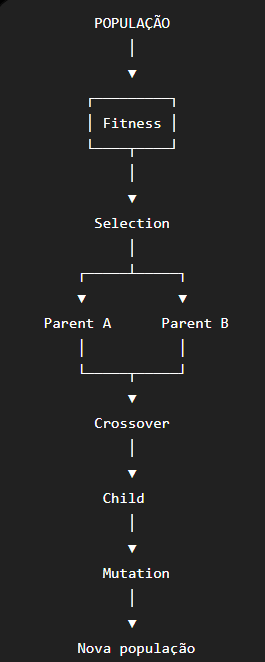

### Genetic loop - Compiling the entire algorithm in a loop

In [21]:
best_solution = None
best_fitness = float("inf")

for generation in range(n_generations):

    fitness_scores = [
        fitness_function(solution)
        for solution in population
    ]

    generation_best_index = np.argmin(
        fitness_scores
    )

    generation_best_fitness = fitness_scores[
        generation_best_index
    ]

    if generation_best_fitness < best_fitness:

        best_fitness = generation_best_fitness

        best_solution = population[
            generation_best_index
        ].copy()

    print(
        f"Generation {generation + 1}: "
        f"Best RMSE = {generation_best_fitness:.4f}"
    )

    new_population = []

    for _ in range(population_size):

        parent1 = tournament_selection(
            population,
            fitness_scores
        )

        parent2 = tournament_selection(
            population,
            fitness_scores
        )

        child = crossover(parent1, parent2)

        child = mutation(
            child,
            mutation_rate
        )

        new_population.append(child)

    population = np.array(new_population)

Generation 1: Best RMSE = 2.0334
Generation 2: Best RMSE = 2.0562
Generation 3: Best RMSE = 2.0357
Generation 4: Best RMSE = 2.0448
Generation 5: Best RMSE = 2.0341
Generation 6: Best RMSE = 2.0446
Generation 7: Best RMSE = 2.0440
Generation 8: Best RMSE = 2.0334
Generation 9: Best RMSE = 2.0334
Generation 10: Best RMSE = 2.0334
Generation 11: Best RMSE = 2.0334
Generation 12: Best RMSE = 2.0332
Generation 13: Best RMSE = 2.0339
Generation 14: Best RMSE = 2.0334
Generation 15: Best RMSE = 2.0336
Generation 16: Best RMSE = 2.0334
Generation 17: Best RMSE = 2.0334
Generation 18: Best RMSE = 2.0334
Generation 19: Best RMSE = 2.0334
Generation 20: Best RMSE = 2.0336
Generation 21: Best RMSE = 2.0334
Generation 22: Best RMSE = 2.0336
Generation 23: Best RMSE = 2.0334
Generation 24: Best RMSE = 2.0334
Generation 25: Best RMSE = 2.0334
Generation 26: Best RMSE = 2.0334
Generation 27: Best RMSE = 2.0334
Generation 28: Best RMSE = 2.0334
Generation 29: Best RMSE = 2.0332
Generation 30: Best RMS

In [22]:
#Notes:
    #It can be observed that, starting from the 11th generation, the individuals have already reached the optimal configuration, 
    #rendering the subsequent ones redundant.

### Best generation solution

In [23]:
#Finally the best solution variables combination
best_solution
best_fitness

np.float64(2.033206104147232)

In [24]:
#Best features selected for incorporation into a regression model
selected_features = feature_names[
    best_solution == 1
]

print(selected_features)
print("Number of features:", best_solution.sum())

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Internet_Access_yes' 'categorical__Family_Income_low'
 'categorical__Family_Income_medium' 'categorical__Teacher_Quality_high'
 'categorical__Teacher_Quality_low' 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_yes'
 'categorical__Parental_Education_Level_high school'
 'categorical__Parental_Education_Level_postgraduate'
 'categorical__Distance_from_Home_far'
 'categorical__Distance_from_Home_near' 'remainder__Hours_Studied'
 'remainder__Attendance' 'remainder__Previous_Scores'
 'remainder__Tutoring_Sessions' 'remainder__Physical_Activity'

## Create the linear regression model using the best features selected by the genetic algorithm model

In [25]:
#Select the features chosen by the Genetic Algorithm
selected_features = best_solution == 1

X_train_ga = X_train_processed[:, selected_features]
X_test_ga = X_test_processed[:, selected_features]

#Model training
model_ga = LinearRegression()

model_ga.fit(
    X_train_ga,
    y_train
)

#Model predict
y_pred_ga = model_ga.predict(
    X_test_ga
)

## Using loss functions to validate the model (metrics comparison)

In [26]:
#Mean absolute error
mae = mean_absolute_error(y_test, y_pred_ga)

#Mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ga))

#r2 error
r2 = r2_score(y_test, y_pred_ga)

#r2 error adjusted
n = len(y_test)
p = X_test_ga.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Results from model
print(f"MAE:  {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.5f}")
print(f"Adjusted R²: {adjusted_r2:.5f}")

MAE:  0.47701
RMSE: 2.03898
R²:   0.73441
Adjusted R²: 0.72888


In [27]:
#Features comparison
print("Baseline features:", X_train_processed.shape[1])
print("GA features:", X_train_ga.shape[1])

Baseline features: 40
GA features: 26


In [28]:
#Notes:
   #The Genetic Algorithm reduced the number of features from 40 to 28 (30% reduction)
   #while maintaining similar predictive performance compared to the baseline Linear Regression model.
   #This suggests that some features had limited impact on the model's predictive performance.

In [29]:
#The selected features
print("\nSelected features:")
for feature in selected_features:
    print(feature)


Selected features:
True
True
False
False
True
True
True
True
True
True
False
False
True
False
True
True
True
True
False
False
False
True
True
True
False
True
False
True
True
True
False
True
False
False
True
True
False
True
True
True


## Saves the trained genetic algorithm models to a file

In [30]:
#This code uses the Joblib library to serialize and save a trained machine learning model (model_ga) as a pickle file (genetic_algorithm_linear_regression.pkl)
joblib.dump(
    model_ga,
    "../models/genetic_algorithm_linear_regression.pkl",
)

['../models/genetic_algorithm_linear_regression.pkl']